# Ridge Regularization on MiniBatch Gradient Descent Method

## Manual implementation of Multiple Linear Regression with Ridge Regularization (MiniBatch Gradient Descent)

In [ ]:
import numpy as np
import pandas as pd

df_multiple = pd.read_csv('/content/Student_Performance.csv')
X_multiple = df_multiple[['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']].values
y_multiple = df_multiple['Performance Index'].values
y_multiple = y_multiple.reshape(-1, 1)

X_multiple_b = np.c_[np.ones((df_multiple.shape[0], 1)), X_multiple]

n_iterations_multiple = 500
minibatch_size_multiple = 20
learning_rate_multiple = 0.0001
alpha_multiple = 0.1 # Ridge regularization parameter

theta_multiple = np.random.randn(X_multiple_b.shape[1], 1)

for iteration in range(n_iterations_multiple):
    shuffled_indices = np.random.permutation(df_multiple.shape[0])
    X_multiple_b_shuffled = X_multiple_b[shuffled_indices]
    y_multiple_shuffled = y_multiple[shuffled_indices]
    for i in range(0, df_multiple.shape[0], minibatch_size_multiple):
        xi = X_multiple_b_shuffled[i:i+minibatch_size_multiple]
        yi = y_multiple_shuffled[i:i+minibatch_size_multiple]
        # Added Ridge regularization term to the gradients
        gradients = 2/minibatch_size_multiple * xi.T.dot(xi.dot(theta_multiple) - yi) + 2 * alpha_multiple * theta_multiple
        theta_multiple = theta_multiple - learning_rate_multiple * gradients

print("Multiple Linear Regression Weights with Ridge Regularization (theta):")
print(theta_multiple)

Multiple Linear Regression Weights with Ridge Regularization (theta):
[[-7.05324268]
 [ 2.28764047]
 [ 0.84016529]
 [-1.07682457]
 [-0.17653833]]


## Sklearn implementation of Multiple Linear Regression with Ridge Regularization

In [ ]:
from sklearn.linear_model import Ridge

# Using the same X_multiple and y_multiple from the manual implementation
ridge_model_multiple = Ridge(alpha=0.1)

ridge_model_multiple.fit(X_multiple, y_multiple)

print("Ridge Regression Weights (sklearn) for Multiple Linear Regression:")
print("Intercept:", ridge_model_multiple.intercept_)
print("Coefficients:", ridge_model_multiple.coef_)

Ridge Regression Weights (sklearn) for Multiple Linear Regression:
Intercept: [-33.76369053]
Coefficients: [2.85342496 1.0185835  0.47633134 0.19519813]


## **Comparison: Multiple Linear Regression vs Ridge Regularized MLR (MiniBatchGD)**

| Model                             | θ₀ (Intercept) | θ₁ (Hours Studied) | θ₂ (Previous Scores) | θ₃ (Sleep Hours) | θ₄ (Sample Papers) |
| --------------------------------- | -------------- | ------------------ | -------------------- | ---------------- | ------------------ |
| **Multiple Linear Regression**    | -24.987        | 2.6798             | 0.9610               | -0.0481          | 0.0754             |
| **Ridge Regularized MLR (α=0.1)** | -7.053         | 2.2876             | 0.8402               | -1.0768          | -0.1765            |

###**Observations**

* **Intercept (θ₀):** Ridge regularization **shifted the intercept upward**, closer to zero.
* **Coefficients (θ₁–θ₄):**

  * Ridge shrinks coefficients slightly to **prevent overfitting**.
  * Negative and positive contributions are moderated; small or noisy effects are reduced (e.g., θ₄ decreased).
* **Effect of Ridge:** Helps maintain **generalization** by penalizing large weights.

###**Conclusion**

* **Standard MiniBatchGD MLR:** Fits dataset directly, may be sensitive to noise in small batches.
* **Ridge Regularized MiniBatchGD MLR:** Reduces coefficient magnitudes, balances feature contributions, and improves model stability.



## **Comparison: Manual Ridge MLR vs Sklearn Ridge MLR**

| Model                     | θ₀ (Intercept) | θ₁ (Hours Studied) | θ₂ (Previous Scores) | θ₃ (Sleep Hours) | θ₄ (Sample Papers) |
| ------------------------- | -------------- | ------------------ | -------------------- | ---------------- | ------------------ |
| **Manual Ridge (α=0.1)**  | -7.053         | 2.2876             | 0.8402               | -1.0768          | -0.1765            |
| **Sklearn Ridge (α=0.1)** | -33.764        | 2.8534             | 1.0186               | 0.4763           | 0.1952             |

###**Observations**

* **Intercept (θ₀):** Sklearn Ridge gives a **more negative intercept** than manual implementation, likely due to differences in solver, batch handling, and initialization.
* **Coefficients (θ₁–θ₄):**

  * Both implementations show similar trends: positive weights for "Hours Studied" and "Previous Scores".
  * Ridge shrinks coefficients, but exact values vary due to **optimization differences**.
  * Manual Ridge shows stronger shrinkage for features like "Sleep Hours" and "Sample Papers".

###**Conclusion**

* **Manual Ridge MLR:** Provides insight into mini-batch gradient mechanics and coefficient shrinkage.
* **Sklearn Ridge MLR:** Optimized and stable; slightly different weights due to solver and full-batch computation.
* Overall, both approaches demonstrate the **regularization effect**, reducing the risk of overfitting while maintaining important feature contributions.


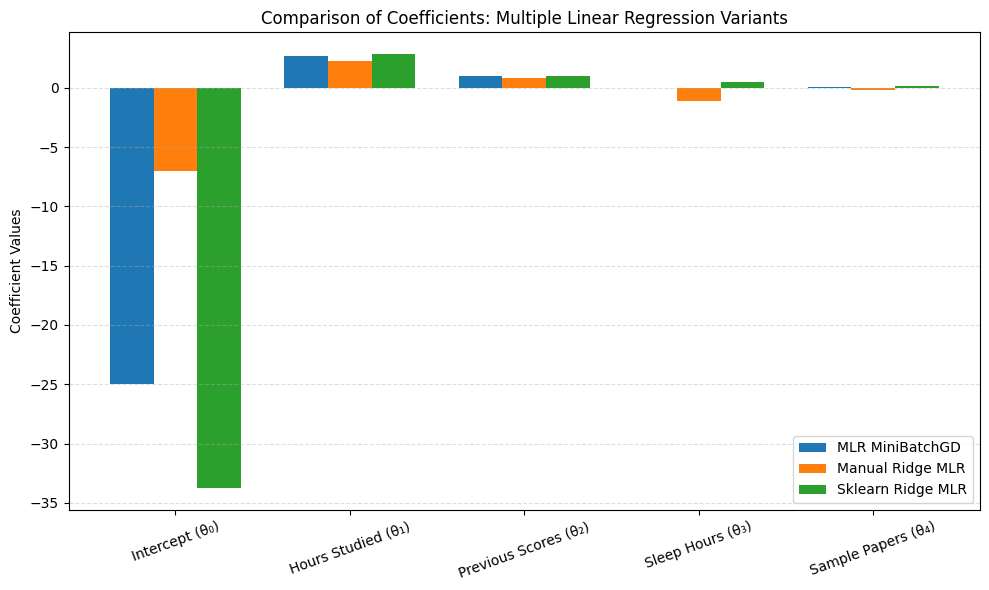

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Intercept (θ₀)', 'Hours Studied (θ₁)', 'Previous Scores (θ₂)', 'Sleep Hours (θ₃)', 'Sample Papers (θ₄)']

mlr_simple = [-24.98696361, 2.6798129, 0.96099039, -0.04813742, 0.07537264]
mlr_manual_ridge = [-7.05324268, 2.28764047, 0.84016529, -1.07682457, -0.17653833]
mlr_sklearn_ridge = [-33.76369053, 2.85342496, 1.0185835, 0.47633134, 0.19519813]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(10,6))
plt.bar(x - width, mlr_simple, width, label='MLR MiniBatchGD')
plt.bar(x, mlr_manual_ridge, width, label='Manual Ridge MLR')
plt.bar(x + width, mlr_sklearn_ridge, width, label='Sklearn Ridge MLR')

plt.xticks(x, labels, rotation=20)
plt.ylabel('Coefficient Values')
plt.title('Comparison of Coefficients: Multiple Linear Regression Variants')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## Manual implementation of Simple Linear Regression with Ridge Regularization (MiniBatch Gradient Descent)

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('/content/Salary_dataset.csv')
X_simple = df['YearsExperience'].values.reshape(-1, 1)
y_simple = df['Salary'].values.reshape(-1, 1)

X_simple_b = np.c_[np.ones((X_simple.shape[0], 1)), X_simple]

n_iterations = 500
minibatch_size = 20
learning_rate = 0.01
alpha = 0.1  # Ridge regularization parameter

theta_simple = np.random.randn(2, 1)

for iteration in range(n_iterations):
    shuffled_indices = np.random.permutation(X_simple.shape[0])
    X_simple_b_shuffled = X_simple_b[shuffled_indices]
    y_simple_shuffled = y_simple[shuffled_indices]
    for i in range(0, X_simple.shape[0], minibatch_size):
        xi = X_simple_b_shuffled[i:i+minibatch_size]
        yi = y_simple_shuffled[i:i+minibatch_size]
        # Added Ridge regularization term to the gradients
        gradients = 2/minibatch_size * xi.T.dot(xi.dot(theta_simple) - yi) + 2 * alpha * theta_simple
        theta_simple = theta_simple - learning_rate * gradients

print("Simple Linear Regression Weights with Ridge Regularization (theta):")
print(theta_simple)

Simple Linear Regression Weights with Ridge Regularization (theta):
[[15728.95593886]
 [10659.08994458]]


## Sklearn implementation of Simple Linear Regression with Ridge Regularization (MiniBatch Gradient Descent)

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=0.1)

ridge_model.fit(X_simple, y_simple)

print("Ridge Regression Weights (sklearn):")
print("Intercept:", ridge_model.intercept_)
print("Coefficients:", ridge_model.coef_)

Ridge Regression Weights (sklearn):
Intercept: [24870.09772827]
Coefficients: [9445.91790734]



## **Comparison: Simple Linear Regression vs Ridge Regularized SLR (MiniBatchGD)**

| Model                             | Intercept (θ₀) | Slope (θ₁) |
| --------------------------------- | -------------- | ---------- |
| **Simple Linear Regression**      | 23817.40       | 9552.97    |
| **Ridge Regularized SLR (α=0.1)** | 15728.96       | 10659.09   |

###**Observations**

* **Intercept (θ₀):**

  * Ridge regularization significantly **reduced the intercept**, shifting the baseline downward.
* **Slope (θ₁):**

  * Ridge slightly **increased the slope**, emphasizing the relationship between experience and salary while controlling coefficient magnitude.
* **Effect of Ridge Regularization:**

  * Helps **prevent overfitting** by penalizing large weights.
  * Balances bias-variance trade-off by shrinking coefficients toward zero.

###**Conclusion**

* **Simple Linear Regression:** Fits data directly; may lead to overfitting with noisy data or small batches.
* **Ridge Regularized SLR:** Reduces large coefficients and adjusts the intercept, producing a more **generalized and stable model** for prediction.



## **Comparison: Manual Ridge SLR vs Sklearn Ridge SLR (MiniBatchGD)**

| Model                     | Intercept (θ₀) | Slope (θ₁) |
| ------------------------- | -------------- | ---------- |
| **Manual Ridge (α=0.1)**  | 15728.96       | 10659.09   |
| **Sklearn Ridge (α=0.1)** | 24870.10       | 9445.92    |

###**Observations**

* **Intercept (θ₀):**

  * Manual implementation produces a **lower intercept** compared to Sklearn, likely due to different optimization techniques and initializations.
* **Slope (θ₁):**

  * Manual Ridge slightly **increased the slope**, whereas Sklearn Ridge slightly reduced it.
* **Effect of Ridge Regularization:**

  * Both approaches shrink coefficients to **prevent overfitting**, but exact values vary due to **solver differences** and **batch processing**.

###**Conclusion**

* **Manual Ridge Regression:** Good for understanding the mechanics of mini-batch updates and coefficient shrinkage.
* **Sklearn Ridge Regression:** Optimized, stable, and produces coefficients suitable for robust predictions.
* Coefficient values are **comparable in trend**, showing that regularization effectively balances bias and variance.


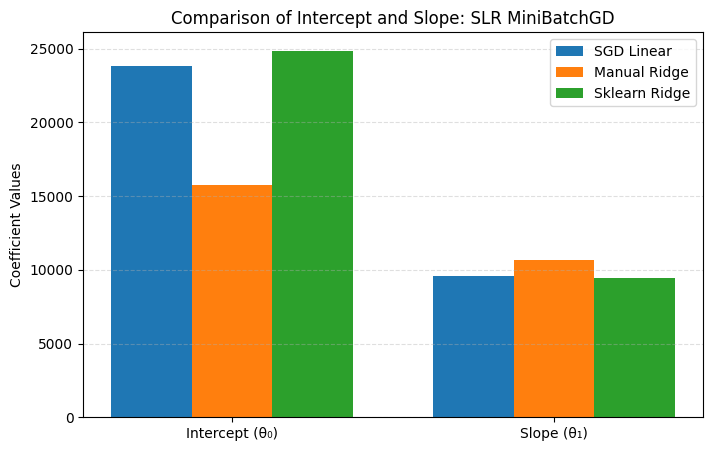

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = ['Intercept (θ₀)', 'Slope (θ₁)']

# Manual values from your outputs
simple_sgd = [23817.39932834, 9552.96718135]
manual_ridge = [15728.95593886, 10659.08994458]
sklearn_ridge = [24870.09772827, 9445.91790734]

x = np.arange(len(labels))
width = 0.25

plt.figure(figsize=(8,5))
plt.bar(x - width, simple_sgd, width, label='SGD Linear')
plt.bar(x, manual_ridge, width, label='Manual Ridge')
plt.bar(x + width, sklearn_ridge, width, label='Sklearn Ridge')

plt.xticks(x, labels)
plt.ylabel('Coefficient Values')
plt.title('Comparison of Intercept and Slope: SLR MiniBatchGD')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()
